In [14]:
%pip install --quiet "pandas>=2.2"


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install qiskit scikit-learn --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install qiskit-aer --upgrade


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
!pip install --upgrade qiskit
!pip install --upgrade qiskit-aer
!pip install --upgrade qiskit-machine-learning

  Using cached qiskit-2.2.1-cp39-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (12 kB)
Using cached qiskit-2.2.1-cp39-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.0 MB)
  Attempting uninstall: qiskit
    Found existing installation: qiskit 1.4.4
    Uninstalling qiskit-1.4.4:
      Successfully uninstalled qiskit-1.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
qiskit-machine-learning 0.8.4 requires qiskit<2.0,>=1.0, but you have qiskit 2.2.1 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
  Using cached qiskit-1.4.4-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
Using cached qiskit-1.4.4-cp39-abi3-manylinux_2_1

In [2]:
# ----------------------------
# 1. Load and preprocess dataset
# ----------------------------
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Load dataset (replace with your path if needed)
data = np.loadtxt('wdbc.data', delimiter=',', dtype=str)
y = data[:, 1]  # Diagnosis: 'B' or 'M'
X = data[:, 2:].astype(float)  # 30 features

# Encode labels: 'B'->0, 'M'->1
le = LabelEncoder()
y = le.fit_transform(y)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 4 PCA components
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print("Dataset ready: X_train.shape =", X_train.shape)


Dataset ready: X_train.shape = (455, 4)


In [2]:
# ----------------------------
# 1. Load and preprocess dataset
# ----------------------------
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Load dataset (replace with your path if needed)
data = np.loadtxt('wdbc.data', delimiter=',', dtype=str)
y = data[:, 1]  # Diagnosis: 'B' or 'M'
X = data[:, 2:].astype(float)  # 30 features

# Encode labels: 'B'->0, 'M'->1
le = LabelEncoder()
y = le.fit_transform(y)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 4 PCA components
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print("Dataset ready: X_train.shape =", X_train.shape)


Dataset ready: X_train.shape = (455, 4)


In [3]:
import pandas as pd

# Encoded dataset = PCA-reduced values, used as rotation angles
encoded_df = pd.DataFrame(
    X_pca,
    columns=[f"Angle_q{i}" for i in range(X_pca.shape[1])]
)

print(encoded_df.head())


   Angle_q0   Angle_q1  Angle_q2  Angle_q3
0  9.192837   1.948583 -1.123166 -3.633731
1  2.387802  -3.768172 -0.529293 -1.118264
2  5.733896  -1.075174 -0.551748 -0.912083
3  7.122953  10.275589 -3.232790 -0.152547
4  3.935302  -1.948072  1.389767 -2.940639


In [4]:
# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encoded dataset = standardized values used as angles
import pandas as pd
encoded_df = pd.DataFrame(
    X_scaled,
    columns=[f"Angle_q{i}" for i in range(X_scaled.shape[1])]
)

# Add label
encoded_df['Label'] = y

print(encoded_df.head())
print("Encoded dataset shape:", encoded_df.shape)

# Save to CSV
encoded_df.to_csv("encoded_dataset.csv", index=False)


   Angle_q0  Angle_q1  Angle_q2  Angle_q3  Angle_q4  Angle_q5  Angle_q6  \
0  1.097064 -2.073335  1.269934  0.984375  1.568466  3.283515  2.652874   
1  1.829821 -0.353632  1.685955  1.908708 -0.826962 -0.487072 -0.023846   
2  1.579888  0.456187  1.566503  1.558884  0.942210  1.052926  1.363478   
3 -0.768909  0.253732 -0.592687 -0.764464  3.283553  3.402909  1.915897   
4  1.750297 -1.151816  1.776573  1.826229  0.280372  0.539340  1.371011   

   Angle_q7  Angle_q8  Angle_q9  ...  Angle_q21  Angle_q22  Angle_q23  \
0  2.532475  2.217515  2.255747  ...  -1.359293   2.303601   2.001237   
1  0.548144  0.001392 -0.868652  ...  -0.369203   1.535126   1.890489   
2  2.037231  0.939685 -0.398008  ...  -0.023974   1.347475   1.456285   
3  1.451707  2.867383  4.910919  ...   0.133984  -0.249939  -0.550021   
4  1.428493 -0.009560 -0.562450  ...  -1.466770   1.338539   1.220724   

   Angle_q24  Angle_q25  Angle_q26  Angle_q27  Angle_q28  Angle_q29  Label  
0   1.307686   2.616665   2.10952

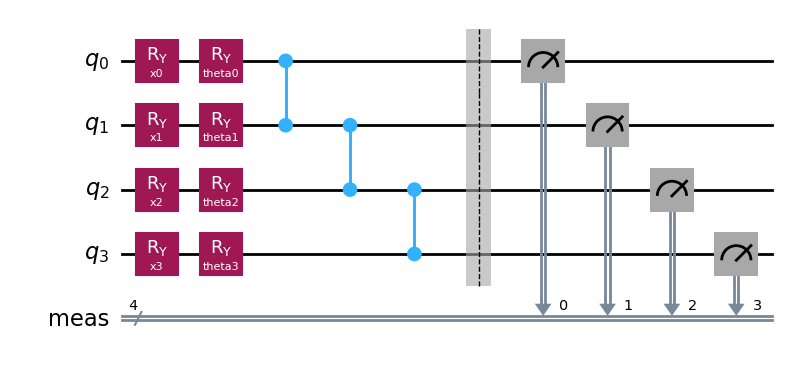

In [5]:
# ----------------------------
# 2. Build 4-qubit variational circuit
# ----------------------------
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

num_qubits = 4

# Parameters
x_params = [Parameter(f'x{i}') for i in range(num_qubits)]
theta_params = [Parameter(f'theta{i}') for i in range(num_qubits)]

# Build circuit
qc = QuantumCircuit(num_qubits)

# Encode features into qubits
for i in range(num_qubits):
    qc.ry(x_params[i], i)

# Variational rotations
for i in range(num_qubits):
    qc.ry(theta_params[i], i)

# Simple entanglement
for i in range(num_qubits - 1):
    qc.cz(i, i+1)

qc.measure_all()
qc.draw('mpl')



In [6]:
# ----------------------------
# 3. Classical training setup
# ----------------------------
# Qniverse executes circuits via `%qexecute` magic
# We'll define a function to compute predicted label probability

from qiskit_aer.primitives import Sampler
sampler = Sampler()  # define once globally

def predict_proba(x_input, theta_values):
    qc_sim = QuantumCircuit(num_qubits)
    
    # Encode features
    for i in range(num_qubits):
        qc_sim.ry(x_input[i], i)
    
    # Apply two variational layers
    for _ in range(2):
        for i in range(num_qubits):
            qc_sim.ry(theta_values[i], i)
        for i in range(num_qubits - 1):
            qc_sim.cz(i, i+1)
    
    qc_sim.measure_all()
    
    result = sampler.run([qc_sim], shots=512).result()
    quasi_probs = result.quasi_dists[0]
    target_state = '1' * num_qubits
    return quasi_probs.get(target_state, 0)


# ----------------------------
# Define loss function
# ----------------------------
def loss_fn(theta_values):
    correct = 0
    for xi, yi in zip(X_train, y_train):
        prob1 = predict_proba(xi, theta_values)
        pred = 1 if prob1 > 0.5 else 0
        correct += (pred == yi)
    return 1 - (correct / len(y_train))  # ✅ fixed line

In [7]:
# ----------------------------
# 5. Optimize rotation angles classically
# ----------------------------
from scipy.optimize import minimize

init_theta = np.random.rand(num_qubits)
# opt_result = minimize(loss_fn, init_theta, method='COBYLA')
# theta_opt = opt_result.x
# Optimize with more iterations
opt_result = minimize(loss_fn, init_theta, method='Nelder-Mead', options={'maxiter': 100})
theta_opt = opt_result.x



In [8]:
correct = 0
for xi, yi in zip(X_test, y_test):
    prob1 = predict_proba(xi, theta_opt)
    pred = 1 if prob1 > 0.5 else 0
    correct += (pred == yi)

accuracy = correct / len(y_test)
print("QNN Test Accuracy (optimized):", round(accuracy * 100, 2), "%")




QNN Test Accuracy (optimized): 62.28 %


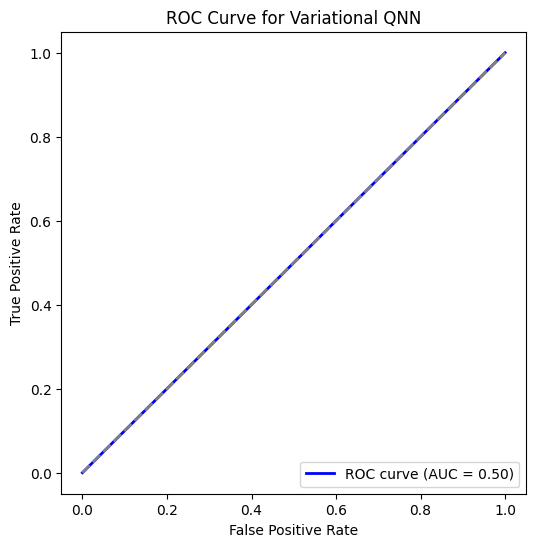

AUC Score: 0.5


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability predictions for the test set
y_scores = []
for xi in X_test:
    prob1 = predict_proba(xi, theta_opt)  # probability of class "1"
    y_scores.append(prob1)

y_scores = np.array(y_scores)

# True labels
y_true = y_test

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Variational QNN")
plt.legend(loc="lower right")
plt.show()

print("AUC Score:", roc_auc)

